# **1. Perkenalan Dataset**


Dataset yang digunakan dalam eksperimen ini adalah **Student Depression Dataset**. Dataset ini memuat hasil survei komprehensif mengenai berbagai aspek kehidupan mahasiswa yang berkaitan dengan kesehatan mental mereka.

* **Deskripsi:** Dataset ini mencakup berbagai variabel, mulai dari informasi demografis (umur, kota), kebiasaan akademik (durasi belajar, tingkat tekanan akademis, kepuasan studi), hingga faktor gaya hidup dan kesehatan (durasi tidur, kebiasaan makan, riwayat depresi).
* **Sumber Data:** Dataset ini merupakan data publik yang diperoleh dari platform Kaggle. 
  * Tautan: [Student Depression Dataset by hopesb](https://www.kaggle.com/datasets/hopesb/student-depression-dataset)
* **Tujuan Eksperimen:** Eksperimen ini bertujuan untuk mengeksplorasi karakteristik data (*Exploratory Data Analysis*), membersihkan dan mempersiapkan data (*Data Preprocessing*), serta pada akhirnya membangun model *Machine Learning* untuk mengklasifikasikan dan memprediksi risiko depresi pada mahasiswa berdasarkan faktor-faktor akademik maupun gaya hidup.
* **Karakteristik Data:** Data berformat tabular (CSV) yang memuat percampuran antara tipe data numerik dan kategorikal, dengan variabel target berupa klasifikasi.


# **2. Import Library**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

In [11]:
file_path = '../Student_Depression_Dataset_raw/Student Depression Dataset.csv'
df = pd.read_csv(file_path)

print("Preview isi dataset:")
display(df.head())

print("\nInformasi struktur dataset:")
df.info()

Preview isi dataset:


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0



Informasi struktur dataset:
<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-nul

# **4. Exploratory Data Analysis (EDA)**


In [12]:
sns.set_theme(style="whitegrid")

Visualisasi Distribusi kelas target

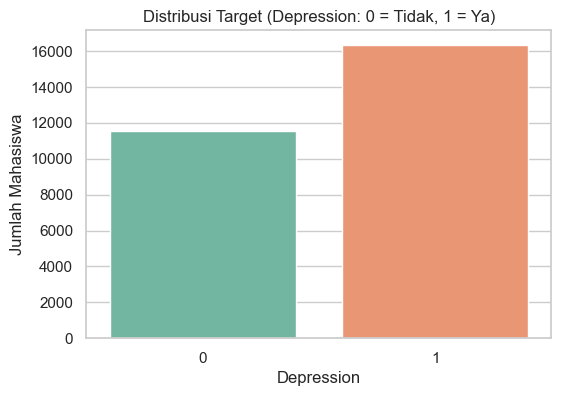

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Depression', palette='Set2')
plt.title('Distribusi Target (Depression: 0 = Tidak, 1 = Ya)', fontsize=12)
plt.ylabel('Jumlah Mahasiswa')
plt.show()

Hubungan fitur numerik dengan target

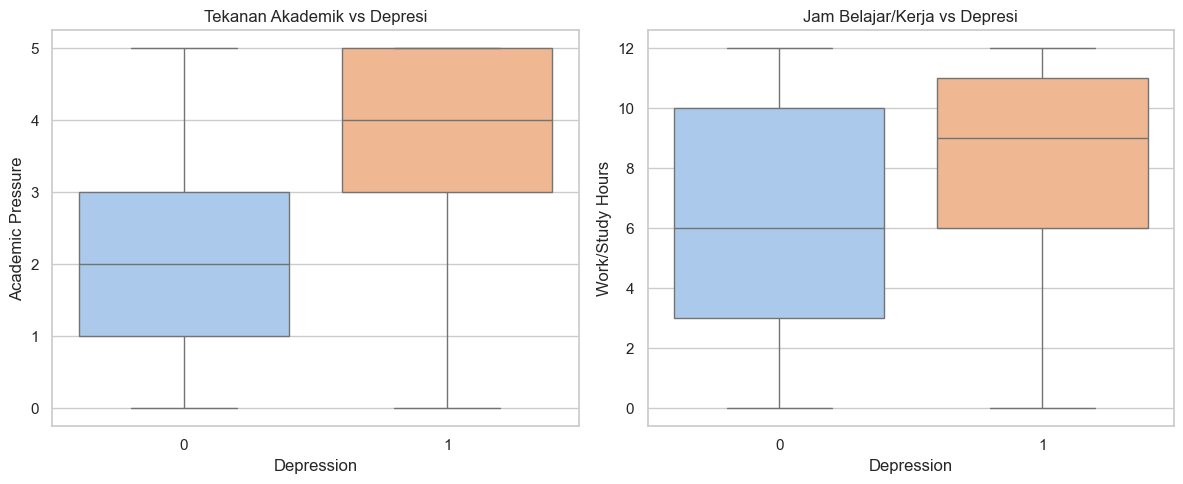

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='Depression', y='Academic Pressure', ax=axes[0], palette='pastel')
axes[0].set_title('Tekanan Akademik vs Depresi')

sns.boxplot(data=df, x='Depression', y='Work/Study Hours', ax=axes[1], palette='pastel')
axes[1].set_title('Jam Belajar/Kerja vs Depresi')

plt.tight_layout()
plt.show()

Hubungan fitur kategorikal dengan target

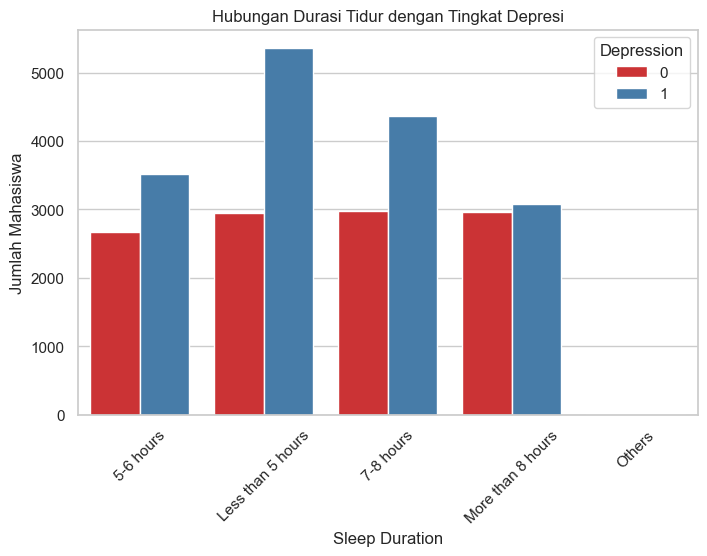

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sleep Duration', hue='Depression', palette='Set1')
plt.title('Hubungan Durasi Tidur dengan Tingkat Depresi', fontsize=12)
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=45) 
plt.show()

### Insight Exploratory Data Analysis (EDA)
Berdasarkan visualisasi data di atas, terdapat beberapa temuan penting yang akan menjadi dasar untuk tahapan *preprocessing* dan pemodelan:

1. **Distribusi Kelas Target (Imbalance Data):** Terdapat perbedaan jumlah antara mahasiswa yang mengalami depresi dan yang tidak (*mild imbalance*). Oleh karena itu, metrik evaluasi model nantinya tidak cukup hanya menggunakan akurasi, melainkan harus menggunakan **F1-Score** atau **ROC-AUC** agar lebih objektif.
2. **Korelasi Tekanan Akademik dan Jam Belajar:** Mahasiswa yang terindikasi depresi mayoritas melaporkan tingkat tekanan akademik yang tinggi (skor 3-5) dan memiliki median jam belajar/kerja yang lebih panjang (sekitar 9 jam) dibandingkan dengan mahasiswa yang tidak depresi (sekitar 6 jam).
3. **Kualitas Data Kategorikal (Durasi Tidur):** Pola menunjukkan mahasiswa dengan durasi tidur "Kurang dari 5 jam" memiliki proporsi depresi tertinggi. Namun, terdapat anomali pada kategori "Others" yang datanya kosong atau terlalu sedikit. Kategori tidak lazim seperti ini harus ditangani atau dibersihkan pada tahap *preprocessing* agar tidak mengganggu kinerja model.

**Kesimpulan untuk Preprocessing:** Data memerlukan pembersihan lebih lanjut, termasuk penghapusan kolom yang tidak relevan (seperti `id`), penanganan *missing values*, pembersihan kategori "Others", serta proses *encoding* dan *scaling* agar data siap dilatih oleh algoritma *Machine Learning*.

# **5. Data Preprocessing**

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
df_clean = df.copy()

print(f"Ukuran data sebelum preprocessing: {df_clean.shape}")

Ukuran data sebelum preprocessing: (27901, 18)


Menghapus kolom yang tidak relevan

In [18]:
if 'id' in df_clean.columns:
    df_clean = df_clean.drop(columns=['id'])

Menangani missing values

In [19]:
df_clean = df_clean.dropna()

Encoding data kategorikal

In [20]:
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

df_clean = df_clean.astype(float)

Scaling fitur numerik

In [21]:
num_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 
            'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

print(f"Ukuran data setelah preprocessing: {df_clean.shape}")
print("\nPreview data siap latih:")
display(df_clean.head())

Ukuran data setelah preprocessing: (27898, 110)

Preview data siap latih:


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression,Gender_Male,...,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
0,1.463201,1.345456,-0.009777,0.893354,-0.693539,-0.01534,-1.121115,-1.488788,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.371450,-0.826195,-0.009777,-1.194113,1.510565,-0.01534,-1.121115,-0.793050,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.055501,-0.102311,-0.009777,-0.425762,1.510565,-0.01534,0.497212,-1.488788,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.443950,-0.102311,-0.009777,-1.404899,-0.693539,-0.01534,-0.851394,1.294167,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,-0.167600,0.621573,-0.009777,0.322191,0.041162,-0.01534,-1.660558,-1.488788,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
